
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [83]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las columnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

# 1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

In [84]:
dft = df[df['isla'] == 'Torgersen']
maxt=dft[["profundidad_pico (mm)"]].max()
mint=dft[["profundidad_pico (mm)"]].min()

print("Maxima profundidad del pico en Torgersen: ", maxt)
print("Minima profundidad del pico en Torgersen: ", mint)



Maxima profundidad del pico en Torgersen:  profundidad_pico (mm)    21.5
dtype: object
Minima profundidad del pico en Torgersen:  profundidad_pico (mm)    15.9
dtype: object


# 2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
**Ayuda:** utilice la función `argmax()`

In [85]:
df['masa_corporal (g)'].argmax()
df2= df.iloc[df['masa_corporal (g)'].argmax()]
df2
isla_mayor_masa = df2["isla"]
especie_mayor_masa = df2["especie"]
genero_mayor_masa = df2["genero"]


print("Isla:",isla_mayor_masa)
print("Especie:",especie_mayor_masa)
print("Género:",genero_mayor_masa)


Isla: Biscoe
Especie: Gentoo
Género: Male



# 3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

In [86]:
dfg = df[df['especie'] != 'Gentoo']
dfg[["masa_corporal (g)"]].mean()
print("Promedio de masa corporal de los pingüinos que no son Gentoo: ", dfg[["masa_corporal (g)"]].mean())


Promedio de masa corporal de los pingüinos que no son Gentoo:  masa_corporal (g)    3714.719626
dtype: object


INCORRETO.... 

# 4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

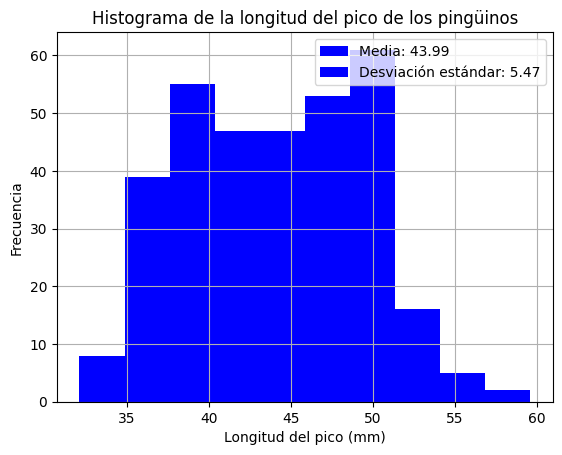

In [87]:
mp=np.round(df["longitud_pico (mm)"].mean(),2)
dp=np.round(df["longitud_pico (mm)"].std(), 2)
df["longitud_pico (mm)"].hist( color='blue', label=f'Media: {mp}')
df["longitud_pico (mm)"].hist( color='blue', label=f'Desviación estándar: {dp}')
plt.title("Histograma de la longitud del pico de los pingüinos")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

# 5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.

In [88]:
dfi=df["isla"].unique()
dfe=df["especie"].unique()

dfi2= df["isla"].value_counts()
dfe2= df["especie"].value_counts()

print("Islas:", dfi)
print("Especies:", dfe)

print("Conteo de pingüinos por isla:")
print(dfi2)


print("Conteo de pingüinos por especie:")
print(dfe2)


Islas: ['Torgersen' 'Biscoe' 'Dream']
Especies: ['Adelie' 'Chinstrap' 'Gentoo']
Conteo de pingüinos por isla:
isla
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64
Conteo de pingüinos por especie:
especie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


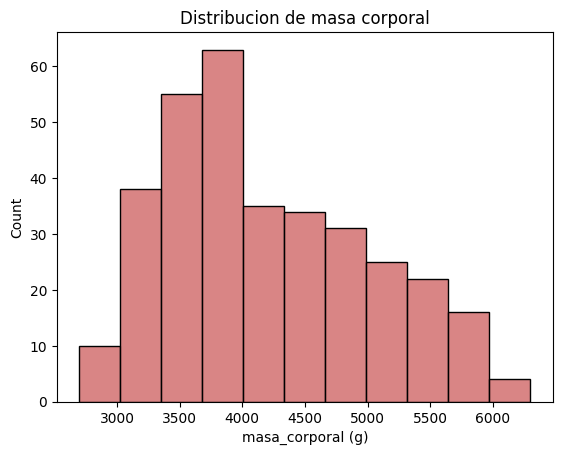

In [89]:
sns.histplot(data= df, x= 'masa_corporal (g)', color= 'indianred' )
plt.title('Distribucion de masa corporal')
plt.show()

MUY BIEN. NOTA 4.5